# Is having a large population beneficial for a country?

Author: Ayşegül Ada BENHÜR

Date: November 2025


    Predictions:

* Countries with larger populations tend to have lower life expectancy.

* Countries with larger populations tend to have lower GDP per capita.



# 1. Library Import

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# 2. Data Import

In [22]:
pd.set_option("display.max_column", None)
df = pd.read_csv("countries_statistics (2).csv")
display(df)

,Country,Year,Continent,Least Developed,Life Expectancy,Population,CO2 emissions,Health expenditure,Electric power consumption,Forest area,GDP per capita,Individuals using the Internet,Military expenditure,People practicing open defecation,People using at least basic drinking water services,Obesity among adults,Beer consumption per capita
0,Albania,2000,Europe,False,73.955,3089027,1.026213,7.233370,1414.703784,28.076642,3860.804627,0.114097,1.246360,0.888853,86.754471,12.8,1.33431
1,Albania,2001,Europe,False,74.288,3060173,1.055496,7.139524,1449.647413,28.123248,4299.546493,0.325798,1.309291,0.836397,86.904070,13.3,1.48995
2,Albania,2002,Europe,False,74.579,3051010,1.232379,6.909341,1351.230796,28.169854,4661.402695,0.390081,1.320034,0.781899,87.451635,13.9,1.28697
3,Albania,2003,Europe,False,74.828,3039616,1.338985,7.063490,1578.165919,28.216460,5000.049363,0.971900,1.336843,0.728191,87.987194,14.4,1.44830
4,Albania,2004,Europe,False,75.039,3026939,1.404059,6.773372,1469.264539,28.263066,5427.732662,2.420388,1.381158,0.675281,88.510583,15.0,1.37617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,Zimbabwe,2011,Africa,False,52.896,12894323,0.884886,8.081738,606.643960,46.165723,2101.824051,8.400000,1.407162,26.876148,67.016076,10.8,2.05000
1900,Zimbabwe,2012,Africa,False,55.032,13115149,0.915735,6.918354,636.248991,46.046633,2375.927006,12.000000,1.859609,26.533231,66.491185,11.1,2.07000
1901,Zimbabwe,2013,Africa,False,56.897,13350378,0.919824,7.110148,608.761669,45.927543,2560.773267,15.500000,1.868420,26.188786,65.966474,11.3,2.12000
1902,Zimbabwe,2014,Africa,False,58.410,13586710,0.889104,8.133525,628.746242,45.808453,2612.455954,16.364740,1.888080,25.832157,65.454108,11.6,2.23000


# 3. Data Manipulation

In [23]:
df = df[df['Year'] == 2015]
display(df)

,Country,Year,Continent,Least Developed,Life Expectancy,Population,CO2 emissions,Health expenditure,Electric power consumption,Forest area,GDP per capita,Individuals using the Internet,Military expenditure,People practicing open defecation,People using at least basic drinking water services,Obesity among adults,Beer consumption per capita
15,Albania,2015,Europe,False,78.025000,2880703,1.603775,4.896312,2309.366503,28.802464,11658.905520,56.900000,1.162304,0.109372,93.394325,21.7,1.48
31,Algeria,2015,Africa,False,76.090000,39728020,3.933496,6.978489,1362.871884,0.821248,12015.640530,38.200000,6.270243,1.155578,93.409562,25.7,0.31
47,Angola,2015,Africa,True,59.398000,27884380,1.135044,2.605795,312.228895,55.653076,7337.569901,22.000000,3.105426,22.534271,54.316928,6.5,3.25
63,Argentina,2015,South America,False,76.068000,43131966,4.301914,10.229339,3074.702071,10.632187,20105.198990,68.043064,0.850129,1.549000,98.966588,28.0,3.39
79,Armenia,2015,Asia,False,74.467000,2925559,1.825292,10.117634,1961.610395,11.574289,9969.664854,59.100834,4.239226,0.011358,99.552567,20.2,0.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1839,United States,2015,North America,False,78.690244,320738994,15.560035,16.524073,12993.965580,33.899723,56762.729450,74.554202,3.477845,0.000000,99.447158,36.7,4.13
1855,Uruguay,2015,South America,False,77.369000,3412013,1.946065,8.292236,3085.189883,10.970175,20217.560440,64.570787,1.820588,0.581574,99.131398,28.4,1.97
1871,Venezuela,2015,South America,False,72.762000,30042973,5.966121,5.776450,3299.011056,53.111955,17743.684000,57.000000,1.161817,4.160450,94.748370,24.7,4.88
1887,Yemen,2015,Asia,True,66.066000,25823488,1.062211,4.841805,250.963212,1.039832,3697.704000,22.550000,3.966891,16.541733,54.757381,13.5,0.03


In [24]:
df['log_population'] = np.log10(df['Population'])
df['log_gdp_per_capita'] = np.log10(df['GDP per capita'])

df['LE'] = df['Life Expectancy']

# 4. Data Description

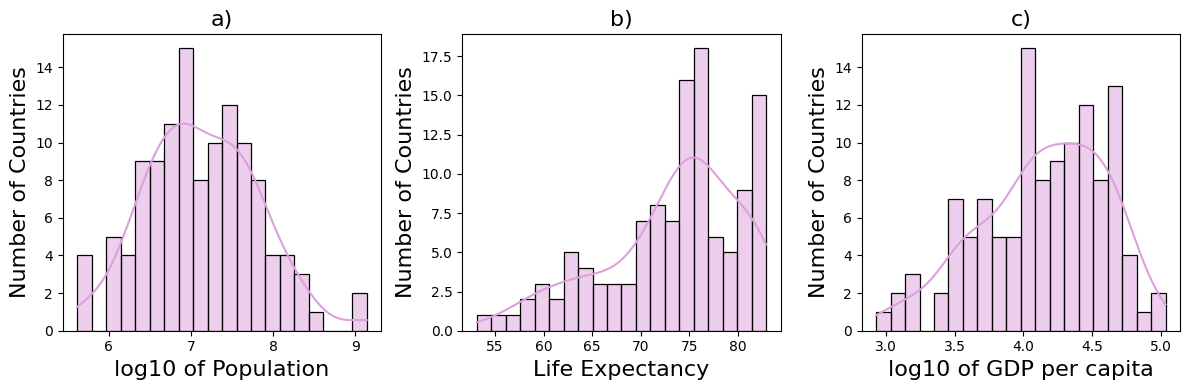

In [25]:
fig1 = plt.figure(figsize = (12, 4))

# Figure 1.a : Distribution of population size   
plt.subplot(1, 3, 1) 
sns.histplot(df['log_population'], bins=20, kde=True, color='plum')
plt.gca().set_xlabel("log10 of Population", size = 16)
plt.gca().set_ylabel("Number of Countries", size = 16)
plt.title("a)", size = 16)

# Figure 1.b : Distribution of life expectancy 
plt.subplot(1, 3, 2) 
sns.histplot(df['Life Expectancy'], bins=20, kde=True, color='plum')
plt.gca().set_xlabel("Life Expectancy", size = 16)
plt.gca().set_ylabel("Number of Countries", size = 16)
plt.title("b)", size = 16)

# Figure 1.c : Distribution of GDP per capita
plt.subplot(1, 3, 3) 
sns.histplot(df['log_gdp_per_capita'], bins=20, kde=True, color='plum')
plt.gca().set_xlabel("log10 of GDP per capita", size = 16)
plt.gca().set_ylabel("Number of Countries", size = 16)
plt.title("c)", size = 16)
plt.tight_layout()


plt.show()

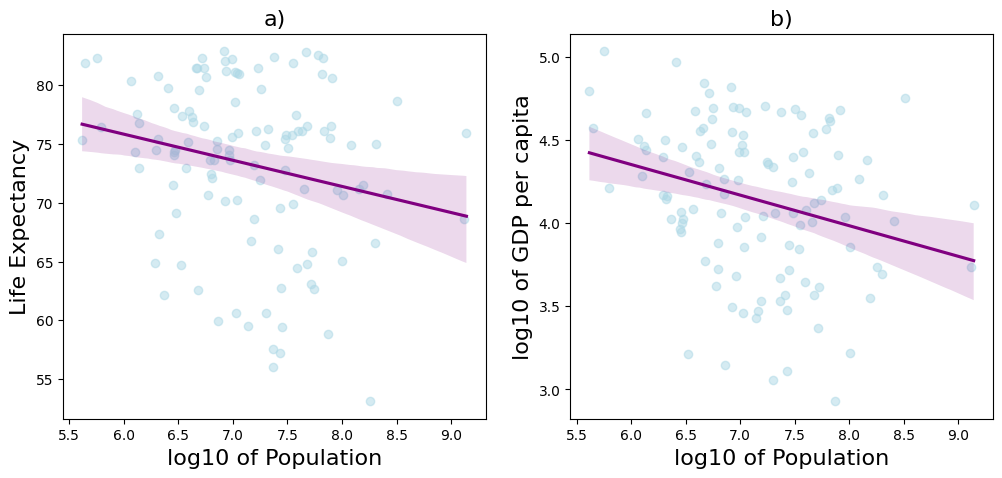

In [26]:
fig2 = plt.figure(figsize=(12, 5))


# Figure 2.a : Life expectancy depending on the population size
plt.subplot(1, 2, 1) 
sns.regplot(data=df, x='log_population', y='Life Expectancy', scatter_kws = {'color': 'lightblue', 'alpha':0.5}, line_kws={'color':'purple'})
plt.gca().set_xlabel("log10 of Population", size = 16)
plt.gca().set_ylabel("Life Expectancy", size = 16)
plt.title("a)", size = 16)

# Figure 2.b : GDP per capita depending on the population size
plt.subplot(1, 2, 2) 
sns.regplot(data=df, x='log_population', y='log_gdp_per_capita', scatter_kws = {'color': 'lightblue', 'alpha':0.5}, line_kws={'color':'purple'})
plt.gca().set_xlabel("log10 of Population", size = 16)
plt.gca().set_ylabel("log10 of GDP per capita", size = 16)
plt.title("b)", size = 16)


plt.show()

# 5. Data Modelling

In [27]:
# Linear regression of population and life expectancy
model = smf.ols(formula = 'LE ~ log_population', data = df).fit()

In [28]:
# Print the results of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     LE   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     5.805
Date:                Sun, 30 Nov 2025   Prob (F-statistic):             0.0175
Time:                        19:30:48   Log-Likelihood:                -396.92
No. Observations:                 119   AIC:                             797.8
Df Residuals:                     117   BIC:                             803.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         89.1787      6.618     13.

In [29]:
# Linear regression of population and GDP per capita
model = smf.ols(formula = 'log_gdp_per_capita ~ log_population', data = df).fit()

In [30]:
# Print the results of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     log_gdp_per_capita   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     9.693
Date:                Sun, 30 Nov 2025   Prob (F-statistic):            0.00233
Time:                        19:30:48   Log-Likelihood:                -69.910
No. Observations:                 119   AIC:                             143.8
Df Residuals:                     117   BIC:                             149.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          5.4564      0.424     12.